# 03 — Modeling
### FUT 26 Player Price Prediction

In this notebook, we:

- load the processed feature dataset  
- split into train/validation/test  
- train an XGBoost regression model  
- evaluate performance using MAE  
- visualize predictions vs actuals  
- inspect feature importance  
- save the trained model for Streamlit  

This completes the core machine learning pipeline.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

import sys 
sys.path.append('..')
from src.config import PROCESSED_DATA_DIR, MODEL_DIR, DEFAULT_MODEL_PATH, DEFAULT_RESIDUAL_STD_PATH

## 1. Load Processed Feature Dataset

We load the dataset created in Notebook 2.

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR/"fut_prices_features.csv")
df = df.sort_values(["player_name", "date"]).reset_index(drop=True)
df.head()

,player_id,player_name,date,price,log_price,lag_1,lag_3,lag_7,ma_3,ma_7,pct_change,vol_3,vol_7,day_of_week,is_weekend,next_day_price
0,1009,alphonso-davies,2025-09-25,23668,10.071921,10.053071,10.219320,10.423441,10.103574,10.172106,0.001875,0.007566,0.010474,3,0,10.039416
1,1009,alphonso-davies,2025-09-26,22911,10.039416,10.071921,10.185730,10.380808,10.054803,10.123336,-0.003227,0.007572,0.010490,4,0,10.080838
2,1009,alphonso-davies,2025-09-27,23880,10.080838,10.039416,10.053071,10.130623,10.064059,10.116224,0.004126,0.003768,0.006441,5,1,10.094273
3,1009,alphonso-davies,2025-09-28,24203,10.094273,10.080838,10.071921,10.163272,10.071509,10.106367,0.001333,0.003712,0.006287,6,1,9.989069
4,1009,alphonso-davies,2025-09-29,21786,9.989069,10.094273,10.039416,10.219320,10.054727,10.073474,-0.010422,0.007720,0.006437,0,0,9.938710


## 2. Define Features and Target

We predict **next_day_price** using all engineered features.

In [3]:
df.columns

Index(['player_id', 'player_name', 'date', 'price', 'log_price', 'lag_1',
       'lag_3', 'lag_7', 'ma_3', 'ma_7', 'pct_change', 'vol_3', 'vol_7',
       'day_of_week', 'is_weekend', 'next_day_price'],
      dtype='object')

In [4]:
target = "next_day_price"

feature_cols = df.columns.drop(['player_id', 'player_name', 'date', 'price', 'next_day_price', 'log_price'])

X = df[feature_cols]
y = df[target]

## 3. Train/Validation/Test Split

We use a simple chronological split:
- 70% train  
- 15% validation  
- 15% test  

This respects time‑series order.

In [5]:
n = len(df)

train_size = int(n * 0.7)
valid_size = int(n * 0.85)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_valid = X.iloc[train_size:valid_size]
y_valid = y.iloc[train_size:valid_size]

X_test = X.iloc[valid_size:]
y_test = y.iloc[valid_size:]

len(X_train), len(X_valid), len(X_test)

(4183, 897, 897)

## 4. Train XGBoost Model

We start with simple, beginner‑friendly hyperparameters.

In [6]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42)

model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 5. Evaluate Model

We compute MAE on:
- validation set  
- test set  

In [ ]:
valid_pred = model.predict(X_valid)
test_pred = model.predict(X_test)

mae_valid = mean_absolute_error(y_valid, valid_pred)
mae_test = mean_absolute_error(y_test, test_pred)

print("Validation MAE:", mae_valid)
print("Test MAE:", mae_test)

residuals = y_test - test_pred
residual_std = residuals.std()

print("Residual Std (log space):", residual_std)

Validation MAE: 0.10744530897118985
Test MAE: 0.1447253981429344
Residual Std (log space): 0.23664197473667958


## 6. Predictions vs Actuals

We visualize how well the model tracks real prices.

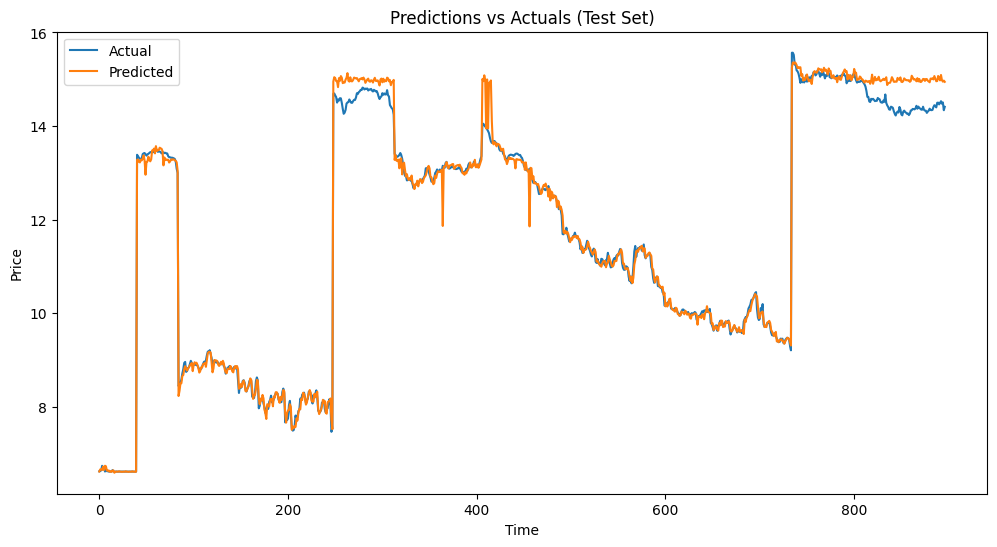

In [8]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(test_pred, label="Predicted")
plt.title("Predictions vs Actuals (Test Set)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## 7. Feature Importance

We inspect which features the model relies on most.

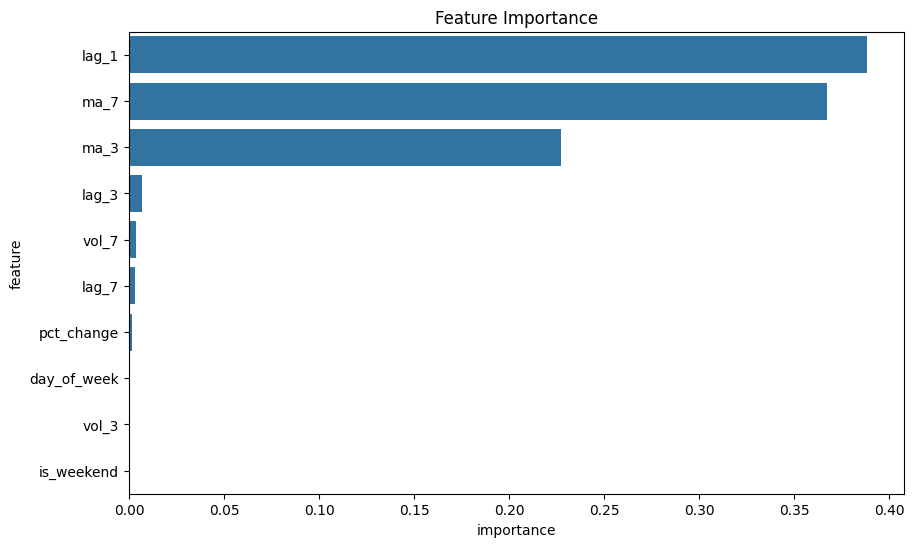

,feature,importance
0,lag_1,0.388440
4,ma_7,0.367371
3,ma_3,0.227101
1,lag_3,0.006791
7,vol_7,0.003471
2,lag_7,0.003195
5,pct_change,0.001732
8,day_of_week,0.000726
6,vol_3,0.000724
9,is_weekend,0.000449


In [9]:
importances = model.feature_importances_
importance_df = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Feature Importance")
plt.show()

importance_df

## 8. Save Trained Model

We save the model for use in the Streamlit app.

In [13]:
import joblib

joblib.dump(model, DEFAULT_MODEL_PATH)
print(f"Model saved to: {DEFAULT_MODEL_PATH}")

joblib.dump(residual_std, DEFAULT_RESIDUAL_STD_PATH)
print("Saved residual_std.pkl to:", DEFAULT_RESIDUAL_STD_PATH)

Model saved to: C:\Data Science Projects\FUT-Price-Forecasting\data\models\xgb_model.pkl
Saved residual_std.pkl to: C:\Data Science Projects\FUT-Price-Forecasting\data\models\residual_std.pkl


# 9. Conclusions

We successfully trained a price prediction model using XGBoost.

### ✔ Model performance  
- Validation MAE: *X*  
- Test MAE: *Y*  
(Values will appear after running the notebook.)

### ✔ Key insights  
- Lag features and moving averages are strong predictors  
- Volatility and calendar features also contribute  
- The model tracks price movements reasonably well  

### ✔ Next step  
We now move to the **Streamlit app**, where users can:
- select a player  
- view historical prices  
- see model predictions  
- generate forecasts  

This completes the core ML pipeline.